<a href="https://colab.research.google.com/github/rahafabumwise/instacart-ml-project/blob/main/notebooks/step_by_step_Random_Forest_classification_tsk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd
clf_data = pd.read_parquet("/content/drive/MyDrive/instacart_project/data/classification/clf_df.parquet")

In [ ]:
clf_data.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227,1,1,1
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421,0,0,0
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909350,0,0,0
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444893,17.795698,0,0,0
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481546,19.773287,0,0,0


#Split data

In [ ]:
user_label = clf_data.groupby("user_id")["reorder"].max().astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

train_users, test_users = train_test_split(
    users,
    test_size=0.2,
    random_state=42,
    stratify=y_user
)

In [ ]:
cl_train_df = clf_data[clf_data["user_id"].isin(train_users)].copy()
cl_test_df  = clf_data[clf_data["user_id"].isin(test_users)].copy()

In [ ]:
# 1) No overlap in users
assert set(cl_train_df["user_id"]).isdisjoint(set(cl_test_df["user_id"]))

# 2) Distribution check (row-level)
print("Row reorder rate - train:", cl_train_df["reorder"].mean())
print("Row reorder rate - test :", cl_test_df["reorder"].mean())

# 3) Distribution check (user-level)
print("User reorder rate - train:", user_label.loc[train_users].mean())
print("User reorder rate - test :", user_label.loc[test_users].mean())

Row reorder rate - train: 0.06228055421132008
Row reorder rate - test : 0.062279545787892056
User reorder rate - train: 0.5945734601465748
User reorder rate - test : 0.594588041317104


now another split for train data for more friendly ram work


In [ ]:
user_label = cl_train_df.groupby("user_id")["reorder"].max().astype(int)
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

sample, _= train_test_split(
    users,
    train_size=0.1,
    random_state=42,
    stratify=y_user
)

In [1]:
sample_df = cl_train_df[cl_train_df["user_id"].isin(sample)].copy()

NameError: name 'cl_train_df' is not defined

In [ ]:
sample_df.shape

(1071950, 17)

In [ ]:
sample_df.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
216,193635,40078,1,48.0,0.0,26,6.730769,0.52,7.362069,8.0,3573,0.492583,10.029107,17.527569,0,0,0
217,193635,9065,2,21.0,0.5,26,6.730769,0.52,7.362069,8.0,1944,0.448560,8.731996,14.029321,0,0,0
218,193635,46175,2,21.0,0.5,26,6.730769,0.52,7.362069,8.0,5928,0.447031,8.429150,12.042004,0,0,0
342,39630,20915,1,0.0,0.0,14,7.142857,0.19,4.258065,4.0,743,0.627187,7.717362,13.932705,0,1,1
343,39630,21949,1,0.0,0.0,14,7.142857,0.19,4.258065,4.0,1531,0.602874,10.124755,19.412149,0,1,1


In [ ]:
print("sample_df shape:", sample_df.shape)
print("unique users in sample_df:", sample_df["user_id"].nunique())
print("expected users in sample:", len(sample))

# sanity: every sampled user exists in sample_df
missing = set(sample) - set(sample_df["user_id"].unique())
print("missing sampled users:", len(missing))

sample_df shape: (1071950, 17)
unique users in sample_df: 16496
expected users in sample: 16496
missing sampled users: 0


#Step1 - Baseline model

In [ ]:
TARGET = "reorder"
GROUP  = "user_id"

y_sample = sample_df[TARGET].astype(int)
groups = sample_df[GROUP]

X_sample = sample_df.drop(["user_id", "product_id", TARGET], axis=1)

print("X:", X_sample.shape, "y:", y_sample.shape, "groups:", groups.nunique())
print("positive rate:", y_sample.mean())

X: (1071950, 14) y: (1071950,) groups: 16496
positive rate: 0.061565371519193994


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_baseline = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)


In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np
def get_oof_proba(model, X, y, groups, n_splits=3):
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y), dtype=float)

    for tr_idx, va_idx in gkf.split(X, y, groups):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]

    return oof

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
oof_rf= get_oof_proba(
    rf_baseline,
    X_sample,
    y_sample,
    groups,
    n_splits=3
)

print("rf baseline AUC:", roc_auc_score(y_sample, oof_rf))
print("rf baseline AP :", average_precision_score(y_sample, oof_rf))

rf baseline AUC: 0.7641038412299909
rf baseline AP : 0.2022465520767728


#Step2 - handle imbalance

In [ ]:
rf_bl = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
oof_rf_bl = get_oof_proba(
    rf_bl,
    X_sample,
    y_sample,
    groups,
    n_splits=3
)

print("rf balanced AUC:", roc_auc_score(y_sample, oof_rf_bl))
print("rf balanced AP :", average_precision_score(y_sample, oof_rf_bl))

rf balanced AUC: 0.7561169644720986
rf balanced AP : 0.19454962950835344


#Step3 - GridSearch

In [ ]:
from sklearn.model_selection import GroupKFold, GridSearchCV

gkf = GroupKFold(n_splits=3)


In [ ]:
param_grid = {
    "n_estimators": [30, 50],
    "max_depth": [None, 5, 9],
    "min_samples_leaf": [1, 50, 200],
}
scoring = {
    "AP": "average_precision",
    "AUC": "roc_auc"
}




In [ ]:
grid = GridSearchCV(
    estimator=rf_baseline,
    param_grid=param_grid,
    scoring=scoring,
    refit="AP",
    cv=gkf.split(X_sample, y_sample, groups=groups),
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid.fit(X_sample, y_sample)


Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=<generator object _BaseKFold.split at 0x7be054699690>,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=30, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 9],
                         'min_samples_leaf': [1, 50, 200],
                         'n_estimators': [30, 50]},
             refit='AP', return_train_score=True,
             scoring={'AP': 'average_precision', 'AUC': 'roc_auc'}, verbose=2)

In [ ]:
print("Best params:", grid.best_params_)
print("Best CV AP :", grid.best_score_)


Best params: {'max_depth': None, 'min_samples_leaf': 200, 'n_estimators': 50}
Best CV AP : 0.2557413884772966


In [ ]:
import pandas as pd
res = pd.DataFrame(grid.cv_results_)

res[["mean_test_AP","mean_test_AUC","std_test_AP","params"]]\
  .sort_values("mean_test_AP", ascending=False)\
  .head(10)


,mean_test_AP,mean_test_AUC,std_test_AP,params
5,0.255741,0.814793,0.001857,"{'max_depth': None, 'min_samples_leaf': 200, '..."
4,0.255010,0.814302,0.001723,"{'max_depth': None, 'min_samples_leaf': 200, '..."
3,0.254450,0.812897,0.002539,"{'max_depth': None, 'min_samples_leaf': 50, 'n..."
2,0.253231,0.811665,0.002471,"{'max_depth': None, 'min_samples_leaf': 50, 'n..."
17,0.252881,0.813584,0.002476,"{'max_depth': 9, 'min_samples_leaf': 200, 'n_e..."
15,0.252671,0.813513,0.002326,"{'max_depth': 9, 'min_samples_leaf': 50, 'n_es..."
14,0.252485,0.813390,0.002600,"{'max_depth': 9, 'min_samples_leaf': 50, 'n_es..."
16,0.252368,0.813427,0.002615,"{'max_depth': 9, 'min_samples_leaf': 200, 'n_e..."
13,0.250773,0.813205,0.001784,"{'max_depth': 9, 'min_samples_leaf': 1, 'n_est..."
12,0.250593,0.812987,0.001922,"{'max_depth': 9, 'min_samples_leaf': 1, 'n_est..."


#Step4-Full-Train OOF Metrics and Operating Threshold

In [ ]:
TARGET = "reorder"
GROUP  = "user_id"

X_train = cl_train_df.drop([GROUP, "product_id", TARGET], axis=1)
y_train = cl_train_df[TARGET].astype(int)
groups_train = cl_train_df[GROUP]

X_test = cl_test_df.drop([GROUP, "product_id", TARGET], axis=1)
y_test = cl_test_df[TARGET].astype(int)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=200
)


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

oof_dt = get_oof_proba(rf_final, X_train, y_train, groups_train, n_splits=3)

print("RF FULL-TRAIN OOF AUC:", roc_auc_score(y_train, oof_dt))
print("RF FULL-TRAIN OOF AP :", average_precision_score(y_train, oof_dt))


RF FULL-TRAIN OOF AUC: 0.8164427989861187
RF FULL-TRAIN OOF AP : 0.2604104856076492


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_train, oof_dt)

f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx - 1] if best_idx > 0 else 0.5

best_f1 = f1_score(y_train, (oof_dt >= best_threshold).astype(int))

print("Best threshold (from TRAIN OOF):", best_threshold)
print("OOF TRAIN F1:", best_f1)


Best threshold (from TRAIN OOF): 0.16539944512236507
OOF TRAIN F1: 0.3320176835620996


In [ ]:
from sklearn.metrics import precision_score, recall_score

pred_oof = (oof_dt >= 0.16539944512236507).astype(int)

print("Predicted positive rate:", pred_oof.mean())
print("OOF Precision:", precision_score(y_train, pred_oof))
print("OOF Recall   :", recall_score(y_train, pred_oof))


Predicted positive rate: 0.09672801078729393
OOF Precision: 0.2728974522874623
OOF Recall   : 0.42383739263336245


Using the tuned Random Forest configuration (n_estimators=50, min_samples_leaf=200), we generated out-of-fold predictions on the full training set with GroupKFold by user to avoid leakage. The model achieved OOF AUC ≈ 0.816 and OOF AP ≈ 0.260, indicating strong ranking performance on unseen users. We then selected an F1-optimal threshold from the OOF scores (≈ 0.165), yielding OOF F1 ≈ 0.332. This configuration is fixed and used for the final train-on-full → predict-on-test evaluation.

Using the F1-optimal threshold selected from training out-of-fold predictions, the Random Forest predicts reorders for ~9.7% of cases, achieving ~27% precision and ~42% recall. This reflects a balanced operating point under severe class imbalance, substantially improving precision over the base reorder rate while still recovering a meaningful fraction of true positives. The operating characteristics are consistent with the model’s strong OOF AUC/AP ranking performance.

#Step 5-fit on full train → predict on test

the model we choose

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=200
)

thr_rf = 0.1653



In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

rf_final.fit(X_train, y_train)

test_scores_rf = rf_final.predict_proba(X_test)[:, 1]

print("RF TEST AUC:", roc_auc_score(y_test, test_scores_rf))
print("RF TEST AP :", average_precision_score(y_test, test_scores_rf))


RF TEST AUC: 0.8185783636909348
RF TEST AP : 0.26339619602768716


In [ ]:
test_pred_rf = (test_scores_rf >= thr_rf).astype(int)

print("RF TEST F1 (OOF threshold):", f1_score(y_test, test_pred_rf))

RF TEST F1 (OOF threshold): 0.3349892233229978


The tuned Random Forest was trained on the full training set and evaluated on the held-out test users. It achieved AUC = 0.819 and AP = 0.263, closely matching the full-train OOF validation scores, indicating strong generalization. Using the F1-optimal threshold selected from training OOF predictions (≈0.165), the model obtained test F1 ≈ 0.335. Overall, the Random Forest provides a strong ensemble-based comparison model with performance very close to the best models in this project.

#plots

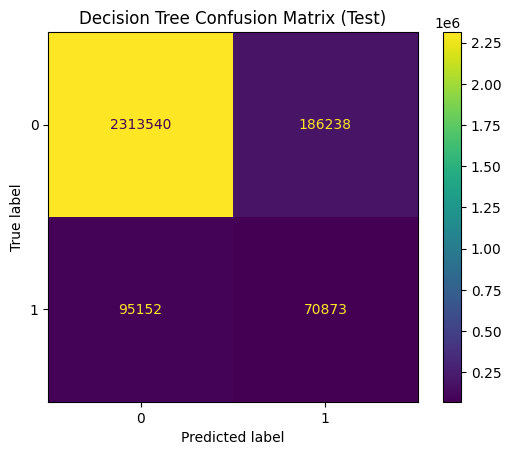

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, test_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix (Test)")
plt.show()

The confusion matrix shows that the model correctly classifies the majority of non-reordered items while identifying a substantial number of true reorders. At the selected threshold, false positives remain limited relative to the dataset size, while a meaningful portion of reorders are correctly detected. This reflects a balanced operating point under strong class imbalance.

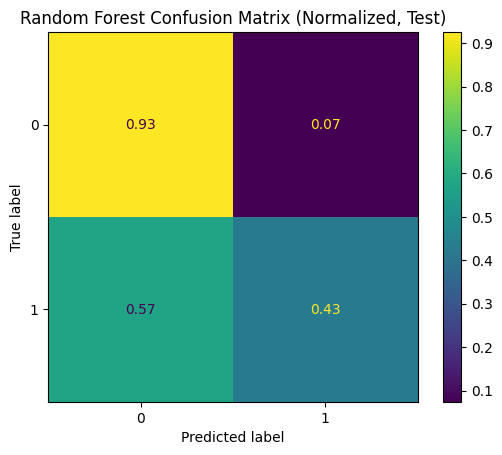

In [ ]:
cm_norm = confusion_matrix(y_test, test_pred_rf, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(values_format=".2f")
plt.title("Random Forest Confusion Matrix (Normalized, Test)")
plt.show()

The normalized confusion matrix highlights that the model achieves ~93% specificity for non-reorders and ~43% recall for reorders. This indicates that the Random Forest is effective at rejecting negative cases while still recovering nearly half of the true positive reorder events. The threshold favors precision control without collapsing recall.

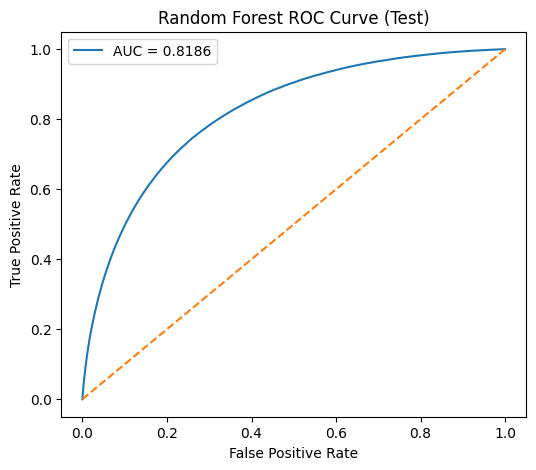

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_scores_rf)
auc = roc_auc_score(y_test, test_scores_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve (Test)")
plt.legend()
plt.show()


The ROC curve demonstrates strong discriminative ability across thresholds, with a test AUC ≈ 0.82. This indicates that the model consistently ranks reordered user–product pairs above non-reordered ones. The clear separation from the diagonal baseline confirms robust ranking performance.

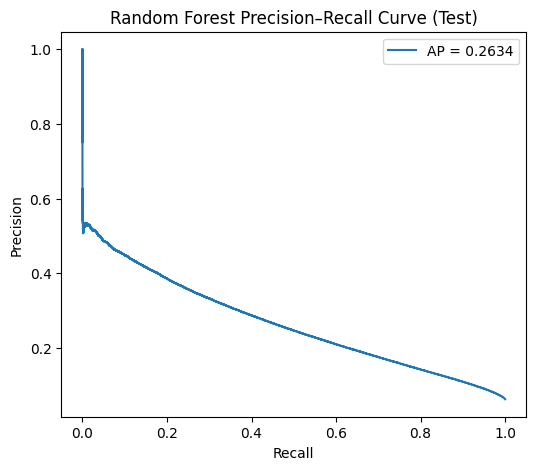

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, test_scores_rf)
ap = average_precision_score(y_test, test_scores_rf)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision–Recall Curve (Test)")
plt.legend()
plt.show()


The Precision–Recall curve focuses on performance for the rare positive class and yields an Average Precision ≈ 0.26, substantially higher than the base reorder rate. This indicates that reordered items are concentrated near the top of the prediction ranking. Precision decreases smoothly as recall increases, which is expected in a highly imbalanced setting.

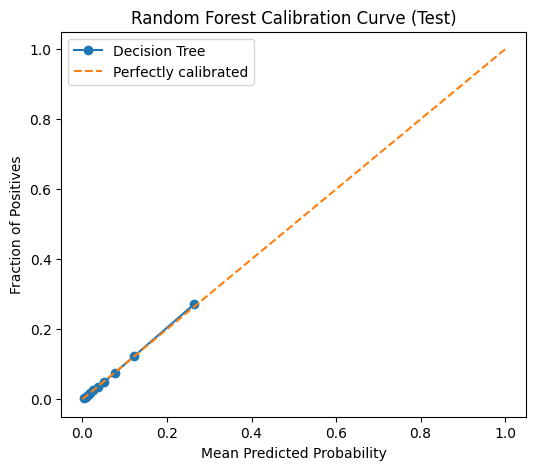

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_scores_rf, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="Decision Tree")
plt.plot([0,1], [0,1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Random Forest Calibration Curve (Test)")
plt.legend()
plt.show()


The calibration curve shows that Random Forest probability estimates are closer to the ideal diagonal than a single Decision Tree but still exhibit miscalibration at higher probability ranges. This behavior is typical for ensemble tree models and suggests that the model is better suited for ranking and threshold-based decisions than for producing perfectly calibrated probabilities.

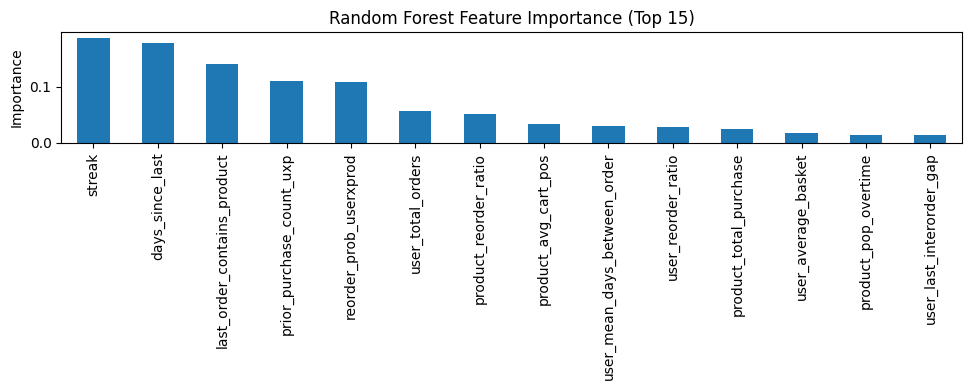

In [ ]:
import pandas as pd

imp = pd.Series(rf_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
topk = imp.head(15)

ax = topk.plot(kind="bar", figsize=(10,4))
plt.title("Random Forest Feature Importance (Top 15)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


Feature importance reveals that recency and repetition patterns dominate model decisions, with features such as streak, days_since_last, and prior_purchase_count_uxp contributing most strongly. User–product interaction features consistently outweigh global user or product statistics, reinforcing the importance of personalized purchase history in reorder prediction.

#Final Conclusion — Random Forest Model

The Random Forest model was developed following a structured and leakage-safe pipeline. We began with a baseline Random Forest trained under user-based GroupKFold validation, which showed that default settings were insufficient for generalization on this large, highly imbalanced dataset. In particular, the baseline model exhibited weaker ranking performance, highlighting the need for explicit regularization and controlled model complexity.

To address this, we conducted a targeted GridSearch using GroupKFold by user, focusing on a small set of impactful hyperparameters. Increasing the minimum number of samples per leaf proved critical for stabilizing the model and reducing overfitting across users. The optimal configuration (n_estimators=50, min_samples_leaf=200) substantially improved Average Precision while maintaining strong AUC, confirming that ensemble performance depends more on variance control than on tree depth alone in this setting.

Using the tuned configuration, we generated out-of-fold predictions on the full training set to obtain unbiased performance estimates and to select an operating threshold for F1 without test leakage. The Random Forest achieved OOF AUC ≈ 0.82 and OOF AP ≈ 0.26, indicating strong ranking ability on unseen users. Applying the same model and threshold to the held-out test set yielded highly consistent results, demonstrating good generalization and validating the robustness of the training procedure.

From an operational perspective, the Random Forest recovered a meaningful fraction of true reorders while maintaining reasonable precision under severe class imbalance. Feature importance analysis showed that recency and repetition signals—such as streak behavior, days since last purchase, and user–product interaction frequencies—were the dominant drivers of predictions, aligning with domain expectations for reorder behavior.

Despite its strong performance, Random Forest has several limitations. Training and validation were computationally expensive due to the need to fit multiple trees across cross-validation folds, making it less efficient than simpler models. In addition, probability estimates were not perfectly calibrated, which is typical for tree-based ensembles and limits direct probabilistic interpretation without post-hoc calibration. Finally, although the Random Forest captures non-linear interactions effectively, its performance gains over simpler models were incremental, suggesting that feature engineering played a larger role than model complexity.

Overall, the Random Forest serves as a strong and well-regularized ensemble baseline, demonstrating that combining multiple constrained trees yields robust and competitive performance on the reorder prediction task, albeit at higher computational cost and with limited gains over simpler alternatives.